# Initial QC

+ Plate 1: 96 samples(60/36), on MEGA kit v2, seq 15 sub-lib X 3 runs
+ Plate 2: 96 samples (88/8), on MEGA kit v2, seq 16 sub-lib X 3 runs
+ ~30 Billion reads per plate
+ Parse workflow has a low [doublet rate](https://support.parsebiosciences.com/hc/en-us/articles/360053107311-What-is-the-expected-doublet-rate#:~:text=Doublet%20rates%20are%20low%2C%20less,through%20the%20Whole%20Transcriptome%20workflow.): ~3% per 100K cells

***

- Moved to Scanpy from Seurat as combined object size of both plates was too much for R
- FC samples included
- 2 filtering steps
- Stage 1
  - Remove cells with < 300 genes OR < 500 reads
  - Remove samples with fewer than 500 cells
- Stage 2
  - UMI - 3 Median absolute deviations
  - Genes - 3 Median absolute deviations
  - Mito - 5%
  - Ribo - 5%
  - Filtering MT genes and MALAT1 removed


In [1]:
# os.system("conda activate eqtl_study") use this locally if using VScode
#%pip install doubletdetection


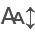

In [2]:
# Import custom utility packages, lists and functions
from init_env import *
from anndata_utils import *
from gene_lists import *
%load_ext memory_profiler

# Set variables
resolutions = [0.1, 0.2, 0.3, 0.4, 0.5]
batch_col = 'plate' # Should we set to plate and sample??

# Load data

In [3]:
# %memit required to memory profile the function
#%memit adata = load_and_process_data(2000, plate1_dir, plate2_dir)
# memit messes with positional args on Hawk
adata = load_and_dwnsmpl_data(None, plate_path)

Processing 1 plate(s) with downsampling to 4000 cells per plate.
Loading plate 2 from /Users/darren/Desktop/eQTL_study_2025/results/02PARSE/combine_plate2/all-sample/DGE_filtered/anndata.h5ad ...
Plate 2 dimensions: (719652, 65793)
Plate 2 matrix dimensions: (719652, 65793)
Only one plate processed; no need to find common genes.
AnnData object with n_obs × n_vars = 4000 × 65793
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'leiden'
    var: 'gene_id', 'gene_name', 'genome', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'norm10k'
    obsp: 'connectivities', 'distances'
Filename: /Users/darren/Desktop/eQTL_study_2025/workflow/scripts/anndata_utils.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    14    230.4 MiB    230.4 MiB           1   @profile
    15                               

In [12]:
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate2_15_70_80__s5       1558    hg38        2142        4314         9159   
plate2_03_37_87__s11     16385    hg38        3431        6377        14360   
plate2_35_11_38__s12     14493    hg38        3826        9602        24971   
plate2_32_55_96__s6      14205    hg38        4740       13554        34772   
plate2_28_73_42__s11     14105    hg38        6021       21701        49846   
...                        ...     ...         ...         ...          ...   
plate2_64_91_36__s2      15658    hg38        4626       18002        39817   
plate2_73_32_52__s11     16246    hg38         305         378          811   
plate2_84_40_78__s16     18145    hg38         394         498         1364   
plate2_94_87_91__s11  14483_FC    hg38         754         909         1843   
plate2_03_27_95__s11     16385    hg38         880        1215         2463   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate2_15_70_80__s5       2               2142                 7.669962   
plate2_03_37_87__s11     13               3431                 8.140898   
plate2_35_11_38__s12      8               3826                 8.249836   
plate2_32_55_96__s6      22               4740                 8.464003   
plate2_28_73_42__s11     16               6021                 8.703175   
...                     ...                ...                      ...   
plate2_64_91_36__s2       6               4626                 8.439664   
plate2_73_32_52__s11      2                305                 5.723585   
plate2_84_40_78__s16      0                394                 5.978886   
plate2_94_87_91__s11      9                754                 6.626718   
plate2_03_27_95__s11      1                880                 6.781058   

                      total_counts  log1p_total_counts  ...  \
bc_wells                                                ...   
plate2_15_70_80__s5    5895.111633            8.682048  ...   
plate2_03_37_87__s11   8865.350469            9.090019  ...   
plate2_35_11_38__s12   8254.367062            9.018619  ...   
plate2_32_55_96__s6    8973.573572            9.102151  ...   
plate2_28_73_42__s11   9335.966707            9.141737  ...   
...                            ...                 ...  ...   
plate2_64_91_36__s2    7663.307736            8.944329  ...   
plate2_73_32_52__s11   1635.980607            7.400609  ...   
plate2_84_40_78__s16   1911.707648            7.556275  ...   
plate2_94_87_91__s11   3369.377434            8.122780  ...   
plate2_03_27_95__s11   3582.213340            8.184015  ...   

                      log1p_total_counts_mt  pct_counts_mt  total_counts_ribo  \
bc_wells                                                                        
plate2_15_70_80__s5                2.337375       0.158674          23.585453   
plate2_03_37_87__s11               1.232499       0.027408          28.495388   
plate2_35_11_38__s12               0.601408       0.009991          42.188007   
plate2_32_55_96__s6                0.805074       0.013783          55.340786   
plate2_28_73_42__s11               2.407207       0.108215          70.562834   
...                                     ...            ...                ...   
plate2_64_91_36__s2                0.472201       0.007875          39.409360   
plate2_73_32_52__s11               0.000000       0.000000           0.000000   
plate2_84_40_78__s16               1.020374       0.092809          13.765312   
plate2_94_87_91__s11               1.081240       0.057825          12.446117   
plate2_03_27_95__s11               1.590645       0.109064          29.101296   

                      log1p_total_counts_ribo  pct_counts_ribo  \
bc_wells                                                         
plate2_15_70_8

# QC metadata

In [5]:
adata.obs['sample'] = adata.obs['sample'].str.replace('sample_', '')
adata = adata[~adata.obs['sample'].str.endswith(tuple(['WGE', 'Hipp', 'Thal']))]
adata.obs['sample'].value_counts() # Cells per sample

sample
1118     148
16024    142
14706    131
13910    130
15658     77
        ... 
14729     17
15248     11
18011      9
14159      8
14521      3
Name: count, Length: 91, dtype: int64

In [6]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

#plt.hist(adata.var['n_cells_by_counts'], bins=500)
#plt.xlabel('N cells expressing > 0')
#plt.ylabel('log(N genes)') # for visual clarity
#plt.axvline(2, color='red')
#plt.yscale('log') 

#sns.jointplot(
#   data=adata.obs,
#   x="log1p_total_counts",
#   y="log1p_n_genes_by_counts",
#   kind="hex",
#)
adata.obs

sample species  gene_count  tscp_count  mread_count  \
bc_wells                                                                      
plate2_15_70_80__s5       1558    hg38        2142        4314         9159   
plate2_03_37_87__s11     16385    hg38        3431        6377        14360   
plate2_46_21_92__s13     15183    hg38         297         356          868   
plate2_35_11_38__s12     14493    hg38        3826        9602        24971   
plate2_38_53_39__s11     14706    hg38         204         225          520   
...                        ...     ...         ...         ...          ...   
plate2_73_32_52__s11     16246    hg38         305         378          811   
plate2_84_40_78__s16     18145    hg38         394         498         1364   
plate2_94_87_91__s11  14483_FC    hg38         754         909         1843   
plate2_03_27_95__s11     16385    hg38         880        1215         2463   
plate2_48_37_09__s11     15218    hg38         168         181          438   

                     leiden  n_genes_by_counts  log1p_n_genes_by_counts  \
bc_wells                                                                  
plate2_15_70_80__s5       2               2142                 7.669962   
plate2_03_37_87__s11     13               3431                 8.140898   
plate2_46_21_92__s13      0                297                 5.697093   
plate2_35_11_38__s12      8               3826                 8.249836   
plate2_38_53_39__s11     18                204                 5.323010   
...                     ...                ...                      ...   
plate2_73_32_52__s11      2                305                 5.723585   
plate2_84_40_78__s16      0                394                 5.978886   
plate2_94_87_91__s11      9                754                 6.626718   
plate2_03_27_95__s11      1                880                 6.781058   
plate2_48_37_09__s11      0                168                 5.129899   

                      total_counts  log1p_total_counts  ...  \
bc_wells                                                ...   
plate2_15_70_80__s5    5895.111633            8.682048  ...   
plate2_03_37_87__s11   8865.350469            9.090019  ...   
plate2_46_21_92__s13   1427.246148            7.264203  ...   
plate2_35_11_38__s12   8254.367062            9.018619  ...   
plate2_38_53_39__s11   1294.217390            7.166434  ...   
...                            ...                 ...  ...   
plate2_73_32_52__s11   1635.980607            7.400609  ...   
plate2_84_40_78__s16   1911.707648            7.556275  ...   
plate2_94_87_91__s11   3369.377434            8.122780  ...   
plate2_03_27_95__s11   3582.213340            8.184015  ...   
plate2_48_37_09__s11    923.131167            6.828854  ...   

                      pct_counts_in_top_500_genes  total_counts_mt  \
bc_wells                                                             
plate2_15_70_80__s5                     41.948632         9.354018   
plate2_03_37_87__s11                    36.169344         2.429791   
plate2_46_21_92__s13                   100.000000         2.642513   
plate2_35_11_38__s12                    32.135841         0.824687   
plate2_38_53_39__s11                   100.000000         0.000000   
...                                           ...              ...   
plate2_73_32_52__s11                   100.000000         0.000000   
plate2_84_40_78__s16                   100.000000         1.774233   
plate2_94_87_91__s11                    82.430364         1.948332   
plate2_03_27_95__s11                    75.062711         3.906912   
plate2_48_37_09__s11                   100.000000         0.000000   

                      log1p_total_counts_mt  pct_counts_mt  total_counts_ribo  \
bc_wells                                                                        
plate2_15_70_80__s5                2.337375       0.158674          23.585453   
plate2_03_37_87__s11               1.232499   

In [7]:
adata.obs[['tscp_count', 'total_counts']] # Why the discrepancy? Duplicates? This is the filtered matrix??!!

tscp_count  total_counts
bc_wells                                      
plate2_15_70_80__s5         4314   5895.111633
plate2_03_37_87__s11        6377   8865.350469
plate2_46_21_92__s13         356   1427.246148
plate2_35_11_38__s12        9602   8254.367062
plate2_38_53_39__s11         225   1294.217390
...                          ...           ...
plate2_73_32_52__s11         378   1635.980607
plate2_84_40_78__s16         498   1911.707648
plate2_94_87_91__s11         909   3369.377434
plate2_03_27_95__s11        1215   3582.213340
plate2_48_37_09__s11         181    923.131167

[3782 rows x 2 columns]

normalizing counts per cell
    finished (0:00:00)


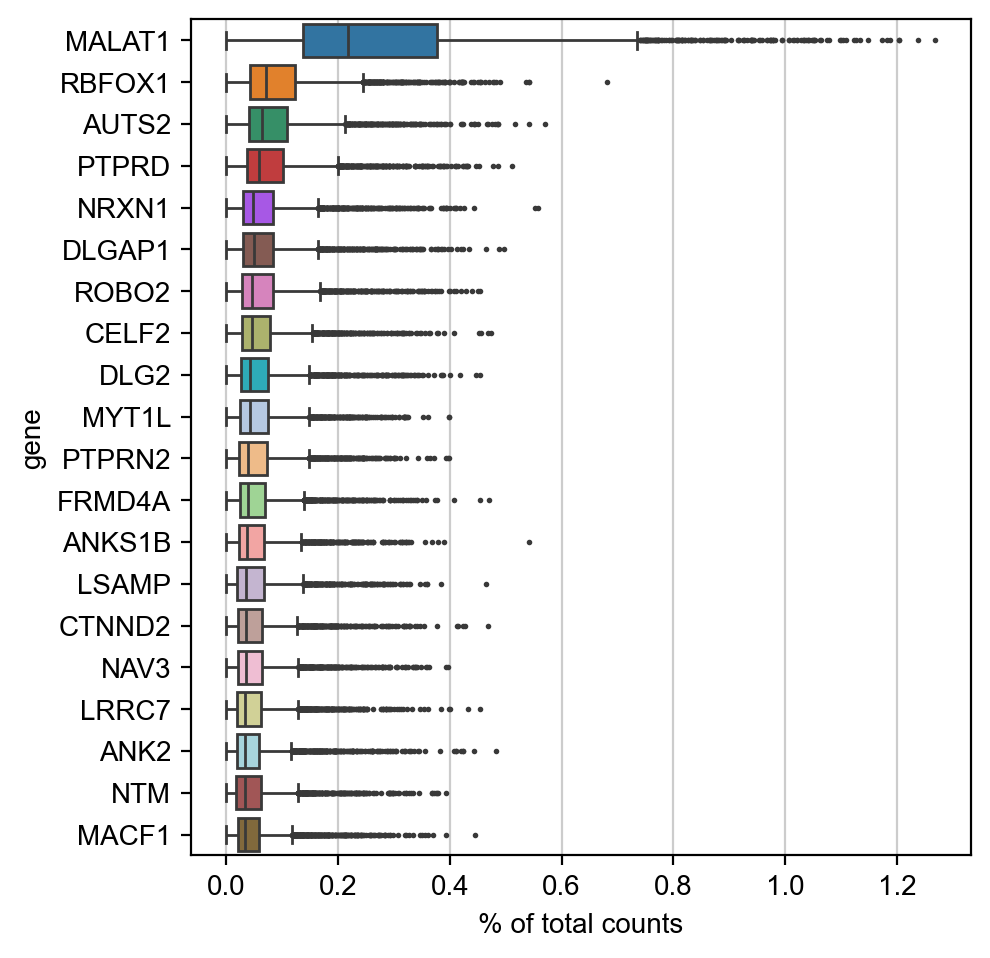

In [8]:
# Most experessed genes - Not such a big deal now?
sc.pl.highest_expr_genes(adata, n_top=20)

In [9]:
# Filter 1
# - Remove cells with < 300 genes OR < 500 reads
# - Remove genes expressed in < 5 cells
# - Remove samples with fewer than 500 cells

#### NOTE: tscp_count != total_counts. Scanpy uses total_counts for filters. Check why these values don't match ####

In [10]:
filter_anndata(adata)
adata.obs['sample'].value_counts() 

Dimensions before applying filter: (3782, 65793)
filtered out 294 cells that have less than 300 genes expressed
filtered out 32725 genes that are detected in less than 5 cells
filtered out 3 samples with < 10 cells.
Dimensions after applying filter: (3479, 33068)


sample
1118     148
16024    142
14706     85
15658     77
13910     76
        ... 
14160     18
14729     17
15183     15
15218     14
15248     10
Name: count, Length: 88, dtype: int64

In [11]:
# Filter 2
# - Doublets
sc.external.pp.scrublet(adata, expected_doublet_rate = 0.03, batch_key = batch_col) # This fails on Hawk 
# Try Doublet detection
# - Compatibility error with Scipy: try csr_matrix to a dense matrix

#clf = doubletdetection.BoostClassifier(n_iters=50) 
#adata_dense = adata.X.toarray() if isinstance(adata.X, np.matrix) elseadata.X.A 
#doublet_scores = clf.fit(adata_dense).doublet_scores() 
#predicted_doublets = clf.predict(p_thresh=1e-16) 

# Add scores and predictions to AnnData 
#adata.obs["doublet_score"] = doublet_scores 
#adata.obs["predicted_doublet"] = predicted_doublets.astype(str)

Running Scrublet


ValueError: `batch_key` must be a column of .obs in the input AnnData object,but 'plate' is not in Index(['sample', 'species', 'gene_count', 'tscp_count', 'mread_count',
       'leiden', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts'],
      dtype='object').

In [ ]:
# Code for Scrublet: failed on Hawk due to memory issues
def plot_doublet_umaps(ann_obj):

    ann_obj.obs["predicted_doublet"] = ann_obj.obs["predicted_doublet"].astype("category")
    sc.pp.normalize_total(ann_obj) # Norm to median total count
    sc.pp.log1p(ann_obj)
    sc.pp.highly_variable_genes(ann_obj, n_top_genes=2000, flavor="seurat_v3", batch_key=batch_col)
    sc.tl.pca(ann_obj, svd_solver='arpack')
    sc.pp.neighbors(ann_obj)
    sc.tl.leiden(ann_obj)
    sc.pl.umap(ann_obj, color=['leiden'])

    return sc.pl.umap(adata, color = ["leiden", "predicted_doublet", "doublet_score"], wspace = 0.1)

plot_doublet_umaps(adata)

In [ ]:
def is_outlier(data, threshold=3, log=False, use_median=True):
    """
    Mimics scuttle::isOutlier to detect outliers in a dataset.
    
    Parameters:
    - data: A pandas Series or numpy array containing numeric values.
    - threshold: Number of MADs or standard deviations to define outliers.
    - log: Whether to log-transform the data before analysis.
    - use_median: If True, use median and MAD; otherwise, use mean and standard deviation.
    
    Returns:
    - A boolean array marking outliers.
    """
    if log:
        data = np.log1p(data)
    
    if use_median:
        center = np.median(data)
        deviation = np.median(np.abs(data - center))  # MAD
    else:
        center = np.mean(data)
        deviation = np.std(data)  # Standard deviation
    
    lower_bound = center - threshold * deviation
    upper_bound = center + threshold * deviation
    
    return (data < lower_bound) | (data > upper_bound)

# Apply the function per sample
adata.obs['mad_outlier'] = adata.obs.groupby('sample')['total_counts'].transform(
    lambda x: is_outlier(x, threshold=3, log=False, use_median=True)
)

# Create the violin plot
fig, ax = plt.subplots(figsize=(10, 6))
sc.pl.violin(
    adata,
    keys='total_counts',
    jitter=0.4,
    groupby='sample',
    rotation=90,
    size=1.5,
    ax=ax,
    show=False, 
    color='Red'
)

# Overlay outlier cells with red dots
outliers = adata.obs.loc[adata.obs['mad_outlier']]
ax.scatter(
    x=outliers['sample'],  # X-coordinates (groupby value)
    y=outliers['total_counts'],  # Y-coordinates (outlier values)
    color='red',
    label='Outliers',
    s=10,
    alpha=0.8
)


In [ ]:

# print(f"Applying cell filters ...")
# adata.obs['mito_gt_5pc'] = adata.obs['pct_counts_mt'] > 5
# adata.obs['ribo_gt_5pc'] = adata.obs['pct_counts_ribo'] > 5

# # Ensure columns are boolean
# columns_to_check = ['mad_outlier', 'predicted_doublet', 'mito_gt_5pc', 'ribo_gt_5pc']
# adata.obs['is_outlier'] = adata.obs[columns_to_check].astype(bool).any(axis=1)


# # Perform the OR operation
# #is_outlier = adata.obs['is_outlier'] | adata.obs['predicted_doublet'] | adata.obs['mito_gt_5pc'] | adata.obs['ribo_gt_5pc']


# print("Counts of outliers for removal: ")
# df = pd.DataFrame({
#     "Counts": [
#         adata.obs['predicted_doublet'].value_counts().get(True, 0),
#         adata.obs['mad_outlier'].value_counts().get(True, 0),
#         adata.obs['mito_gt_5pc'].value_counts().get(True, 0),
#         adata.obs['ribo_gt_5pc'].value_counts().get(True, 0),
#         adata.obs['is_outlier'].value_counts().get(True, 0)
#     ]
# }, index=['predicted_doublet', 'mad_outlier', 'mito_gt_5pc', 'ribo_gt_5pc', 'is_outlier'])

# print(df)

# print(f"Dimensions before cell filter: {adata.shape}")
# adata = adata[adata.obs['is_outlier'] == False].copy()
# print(f"Dimensions after cell filter: {adata.shape}")
# gc.collect()

# print(f"Applying gene filters: rm mito genes and MALAT1")
# # Step 1: Identify mitochondrial genes
# mito_genes = adata.var_names.str.startswith('MT-')  # For human

# # Step 2: Add MALAT1 to the removal list
# genes_to_remove = mito_genes | (adata.var_names == 'MALAT1')

# # Step 3: Subset the AnnData object, keeping only genes not in the removal list
# adata = adata[:, ~genes_to_remove].copy()

# # Confirm changes
# print(f"Number of genes removed: {genes_to_remove.sum()}")
# print(f"Dimensions object after gene filter: {adata.shape}")

# import pandas as pd
# import scanpy as sc
# import gc

def filter_cells_and_genes(adata):
    """
    Apply filters to cells and genes in the AnnData object, modifying in place.
    
    Cell filters:
        - Mitochondrial gene percentage > 5%
        - Ribosomal gene percentage > 5%
        - MAD outliers
        - Predicted doublets
    
    Gene filters:
        - Remove mitochondrial genes (MT-)
        - Remove MALAT1
    
    Parameters:
        adata (AnnData): The AnnData object to filter.
    
    Returns:
        AnnData: The filtered AnnData object (modifies in place).
    """
    print(f"Applying cell filters ...")
    
    # Applying cell filters directly in place
    adata.obs['mito_gt_5pc'] = adata.obs['pct_counts_mt'] > 5
    adata.obs['ribo_gt_5pc'] = adata.obs['pct_counts_ribo'] > 5

    # Ensure columns are boolean
    columns_to_check = ['mad_outlier', 'predicted_doublet', 'mito_gt_5pc', 'ribo_gt_5pc']
    adata.obs['is_outlier'] = adata.obs[columns_to_check].astype(bool).any(axis=1)

    # Report counts of outliers for removal
    print("Counts of outliers for removal: ")
    df = pd.DataFrame({
        "Counts": [
            adata.obs['predicted_doublet'].value_counts().get(True, 0),
            adata.obs['mad_outlier'].value_counts().get(True, 0),
            adata.obs['mito_gt_5pc'].value_counts().get(True, 0),
            adata.obs['ribo_gt_5pc'].value_counts().get(True, 0),
            adata.obs['is_outlier'].value_counts().get(True, 0)
        ]
    }, index=['predicted_doublet', 'mad_outlier', 'mito_gt_5pc', 'ribo_gt_5pc', 'is_outlier'])

    print(df)

    print(f"Dimensions before cell filter: {adata.shape}")
    adata = adata[adata.obs['is_outlier'] == False]  # Apply cell filter directly
    print(f"Dimensions after cell filter: {adata.shape}")
    gc.collect()

    # Applying gene filters
    print(f"Applying gene filters: rm mito genes and MALAT1")
    
    # Step 1: Identify mitochondrial genes
    mito_genes = adata.var_names.str.startswith('MT-')  # For human

    # Step 2: Add MALAT1 to the removal list
    genes_to_remove = mito_genes | (adata.var_names == 'MALAT1')

    # Step 3: Subset the AnnData object directly, keeping only genes not in the removal list
    adata = adata[:, ~genes_to_remove]  # Apply gene filter directly

    # Confirm changes
    print(f"Number of genes removed: {genes_to_remove.sum()}")
    print(f"Dimensions object after gene filter: {adata.shape}")

    return adata


filter_cells_and_genes(adata)


In [ ]:
# Save
adata.write(scanpy_dir + f'adata_qc_{plate}.h5ad')